# 📊 People Analytics — Análisis de Rotación de Talento
### ABC Corporation · Data Analytics Project

---

## 🧠 Contexto de Negocio

El área de Recursos Humanos de ABC Corporation ha analizado los registros históricos de rotación de personal y ha identificado un patrón consistente: la salida de empleados no afecta de forma homogénea a toda la organización.

Los datos iniciales muestran que la rotación se concentra en determinados departamentos, lo que está generando un impacto directo en la estabilidad de los equipos y en la continuidad de la relación con los clientes.

Además, se observan relaciones entre la rotación y factores laborales como la carga de trabajo (horas extra), lo que sugiere que la salida de empleados podría estar asociada a condiciones específicas del puesto.

---
## 🗂️ Variables seleccionadas

Se han seleccionado 8 variables clave para el análisis de rotación de empleados, organizadas según su naturaleza y la pregunta de negocio que permiten responder.

### 📊 Tabla de variables

| Variable | Tipo | Pregunta de negocio |
|---|---|---|
| `department`, `jobrole` | Organizacional | ¿En qué áreas o roles se concentra la rotación? |
| `monthlyincome` | Compensación | ¿El nivel salarial influye en la decisión de abandono? |
| `yearsatcompany` | Antigüedad | ¿Los empleados con menor tiempo en la empresa presentan mayor riesgo de salida? |
| `jobsatisfaction` | Experiencia laboral | ¿La satisfacción laboral reduce la probabilidad de rotación? |
| `overtime` | Carga de trabajo | ¿Las horas extra están asociadas a una mayor rotación? |
| `attrition` | Variable objetivo | ¿Qué empleados han abandonado la organización? |

---

### 🧩 Nota metodológica

Las variables seleccionadas permiten analizar la rotación desde tres dimensiones principales:

- **Estructura organizativa** (departamento y rol)
- **Condiciones laborales** (salario, horas extra, satisfacción)
- **Ciclo de vida del empleado** (antigüedad)

## ⚙️ 1. Librerías y Configuración

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

## 📂 2. Carga de Datos

In [ ]:
# ── Carga del CSV ──────────────────────────────────────────────────────────
df = pd.read_csv("dataset/ABC_Corp.csv")

print("=== FASE 1: EXPLORACIÓN GLOBAL ===")
print(f"Dimensiones macro: {df.shape[0]} registros y {df.shape[1]} columnas.")

print("\nInformación estructural del dataset:")
print(df.info())  # tipos de variables correctos, presencia de valores nulos, no todas las variables son importantes.

=== FASE 1: EXPLORACIÓN GLOBAL ===
Dimensiones macro: 1474 registros y 35 columnas.

Información estructural del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1474 entries, 0 to 1473
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1401 non-null   float64
 1   Attrition                 1474 non-null   object 
 2   BusinessTravel            1357 non-null   object 
 3   DailyRate                 1474 non-null   int64  
 4   Department                1445 non-null   object 
 5   DistanceFromHome          1474 non-null   int64  
 6   Education                 1474 non-null   int64  
 7   EducationField            1416 non-null   object 
 8   EmployeeCount             1474 non-null   int64  
 9   EmployeeNumber            1474 non-null   int64  
 10  EnvironmentSatisfaction   1474 non-null   int64  
 11  Gender                    1474 non-null   object 
 

## 🔎 3. LIMPIEZA

In [56]:
# ── Selección de variables relevantes ──────────────────────────────────────
columns_hr = [
    'EmployeeNumber', 
    'Department', 'JobRole', 
    'MonthlyIncome', 
    'YearsAtCompany', 
    'JobSatisfaction', 
    'OverTime', 
    'Attrition' #
]

df_clean = df[columns_hr].copy()
print(f"✅ Dataset listo: {df_clean.shape[0]} empleados · {df_clean.shape[1]} variables")

df_clean.info() # determinamos 4 variables categóricas (Department, JobRole, OverTime, Attrition) y 4 numéricas (EmployeeNumber, MonthlyIncome, YearsAtCompany, JobSatisfaction))

✅ Dataset listo: 1474 empleados · 8 variables
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1474 entries, 0 to 1473
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   EmployeeNumber   1474 non-null   int64  
 1   Department       1445 non-null   object 
 2   JobRole          1474 non-null   object 
 3   MonthlyIncome    1460 non-null   float64
 4   YearsAtCompany   1474 non-null   int64  
 5   JobSatisfaction  1445 non-null   float64
 6   OverTime         1430 non-null   object 
 7   Attrition        1474 non-null   object 
dtypes: float64(2), int64(2), object(4)
memory usage: 92.3+ KB


In [57]:
# ── Estandarización: snake_case ──────────────────────────────
df_clean.columns = df_clean.columns.str.lower().str.strip().str.replace(" ", "_")

for col in df_clean.select_dtypes(include="object").columns:
    df_clean[col] = df_clean[col].str.lower().str.strip().str.replace(" ", "_")

print("✅ Columnas y valores estandarizados a snake_case.")
print(f"Columnas actuales: {df_clean.columns.tolist()}")

✅ Columnas y valores estandarizados a snake_case.
Columnas actuales: ['employeenumber', 'department', 'jobrole', 'monthlyincome', 'yearsatcompany', 'jobsatisfaction', 'overtime', 'attrition']


In [58]:
# ── Gestión de duplicados por ID de empleado ───────────────────────────────────────
total_duplicados = df_clean.duplicated(subset=["employeenumber"]).sum()
pct_duplicados   = (total_duplicados / len(df_clean)) * 100

print(f"🔍 Empleados repetidos: {total_duplicados} ({pct_duplicados:.2f}% del dataset)")

df_clean.drop_duplicates(subset=["employeenumber"], keep="first", inplace=True)
df_clean.reset_index(drop=True, inplace=True)

print(f"✅ Dataset libre de duplicados: {df_clean.shape[0]} empleados únicos.")

🔍 Empleados repetidos: 4 (0.27% del dataset)
✅ Dataset libre de duplicados: 1470 empleados únicos.


In [59]:
# ── Gestión de valores nulos ────────────────────────────────

# 1. Revisión inicial de nulos
print("📊 Nulos antes de limpiar:")

cols = ["monthlyincome", "jobsatisfaction", "department", "overtime"]

print(df_clean[cols].isnull().mean() * 100)
print("-" * 40)


# 📊 Variables con muy bajo % de nulos (<5%) → se imputan para no perder información


# 🔢 Numérica: imputación por mediana según jobrole
df_clean["monthlyincome"] = df_clean["monthlyincome"].fillna(
    df_clean.groupby("jobrole")["monthlyincome"].transform("median")
)


# 🏷️ Categóricas: imputación por moda
for col in cols[1:]:  # todas menos monthlyincome
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])


# 📊 Evaluación final de nulos
nulos_restantes = df_clean[cols].isnull().sum().sum()
porcentaje_nulos_final = (nulos_restantes / (len(df_clean) * len(cols))) * 100


# 📢 Resumen final
print("✅ Imputación completada")
print(f"Filas: {len(df_clean)}")
print(f"Nulos restantes: {nulos_restantes}")
print(f"% nulos final: {porcentaje_nulos_final:.2f}%")

📊 Nulos antes de limpiar:
monthlyincome      0.952381
jobsatisfaction    1.972789
department         1.972789
overtime           2.993197
dtype: float64
----------------------------------------
✅ Imputación completada
Filas: 1470
Nulos restantes: 0
% nulos final: 0.00%


In [60]:
# ── Rango de valores: analizar si hay valores atípicos ───────────────

variables_num = ["monthlyincome", "yearsatcompany", "jobsatisfaction"]

display(df_clean[variables_num].describe().T)

,count,mean,std,min,25%,50%,75%,max
monthlyincome,1470.0,6488.861905,4702.485645,1009.0,2905.25,4907.0,8260.25,19999.0
yearsatcompany,1470.0,7.008163,6.126525,0.0,3.00,5.0,9.00,40.0
jobsatisfaction,1470.0,2.757143,1.108265,1.0,2.00,3.0,4.00,4.0


## 📈 4. ANÁLISIS

#### 1. ¿Cómo está estructurada la empresa?

Antes de buscar causas de la fuga, necesitamos entender **quiénes son** nuestros empleados
y cómo está organizada la plantilla. Las variables categóricas nos dicen dónde trabaja cada persona
y qué rol desempeña — son el mapa organizativo sobre el que luego leeremos el riesgo.

In [61]:
# ── Distribución por Departamento y Puesto ──────────────────────────────────
print("🏢 DISTRIBUCIÓN POR DEPARTAMENTO")
display(df_clean["department"].value_counts(normalize=True).mul(100).round(1).to_frame(name="%"))

print("💼 DISTRIBUCIÓN POR PUESTO / ROL")
display(df_clean["jobrole"].value_counts(normalize=True).mul(100).round(1).to_frame(name="%"))

🏢 DISTRIBUCIÓN POR DEPARTAMENTO


,%
department,
research_&_development,65.9
sales,29.9
human_resources,4.3


💼 DISTRIBUCIÓN POR PUESTO / ROL


,%
jobrole,
sales_executive,22.2
research_scientist,19.9
laboratory_technician,17.6
manufacturing_director,9.9
healthcare_representative,8.9
manager,6.9
sales_representative,5.6
research_director,5.4
human_resources,3.5


#### 2. ¿Cuál es el perfil económico y laboral del empleado típico?

Las variables numéricas nos describen las condiciones de trabajo: cuánto cobra, cuánto tiempo lleva
en la empresa y cómo valora su trabajo. Usamos la **mediana** como referencia
porque el salario y la antigüedad tienen outliers que distorsionarían la media.

In [62]:
print("📊 El empleado típico:")
display(df_clean[["monthlyincome", "yearsatcompany", "jobsatisfaction"]].median().to_frame(name="Mediana").round(1))

📊 El empleado típico:


,Mediana
monthlyincome,4907.0
yearsatcompany,5.0
jobsatisfaction,3.0


#### 3. ¿Cómo de grave es el problema?

Antes de buscar causas, necesitamos dimensionar el problema: ¿qué porcentaje de la plantilla
está abandonando la empresa? Este dato es el punto de partida del análisis de riesgo.

> ⚠️ Un porcentaje global puede parecer moderado, pero ocultar segmentos críticos.
> Este número solo cobra sentido cuando lo cruzamos con los factores de riesgo.

In [ ]:
# ── Tasa global de attrition ────────────────────────────────────────────────
# Este es el punto de partida del problema: ¿cómo de grave es la fuga?

print("📈 Tasa de Fuga General (Attrition):")
display(df_clean["attrition"].value_counts(normalize=True).mul(100).round(1).to_frame(name="%"))

# Resultado: **16,1%** — ligeramente por encima del benchmark del sector tecnológico (~15%). Un porcentaje que no es de alarma, pero que puede ocultar concentraciones muy localizadas.

📈 Tasa de Fuga General (Attrition):


,%
attrition,
no,83.9
yes,16.1


#### 4. ¿Qué factores numéricos se asocian con la fuga?

El heatmap de correlación nos permite relacionar todas las variables numéricas con `attrition`
de un solo vistazo. Nos indica **en qué dirección y con qué intensidad** se mueve cada variable
respecto a la fuga.

**Cómo interpretar el resultado:**
| Valor | Significado |
|---|---|
| Cercano a **+1** | Cuando la variable sube, la fuga sube |
| Cercano a **-1** | Cuando la variable sube, la fuga baja |
| Cercano a **0** | Sin relación lineal apreciable |

**Referencia práctica en datos de RRHH:**
- `0.1 – 0.2` — débil, casi ruido
- `0.2 – 0.3` — moderada, vale la pena investigar
- `> 0.3` — relevante

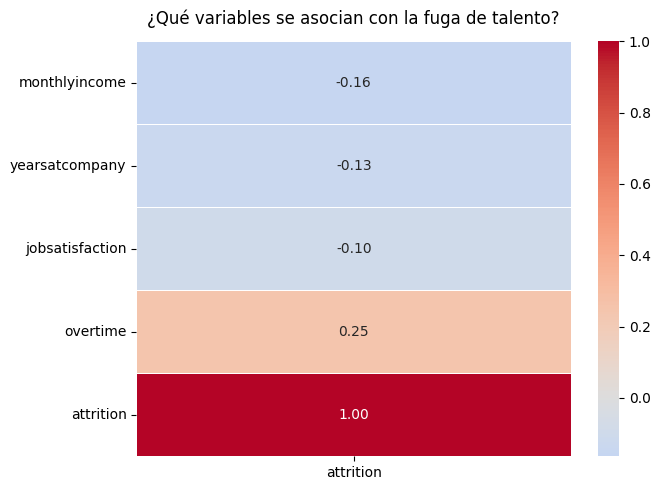

In [ ]:
# ── Heatmap de correlación con attrition ────────────────────────────────────
df_corr = df_clean[["monthlyincome", "yearsatcompany", "jobsatisfaction"]].copy()
df_corr["overtime"]  = (df_clean["overtime"]  == "yes").astype(int) # convertimos overtime a 1/0 para que se incluya en la matriz de correlación
df_corr["attrition"] = (df_clean["attrition"] == "yes").astype(int) # convertimos attrition a 1/0 para que se incluya en la matriz de correlación

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    df_corr.corr()[["attrition"]].sort_values("attrition"),
    annot=True, fmt=".2f", cmap="coolwarm", center=0,
    linewidths=0.5, ax=ax
)
ax.set_title("¿Qué variables se asocian con la fuga de talento?", pad=12)
plt.tight_layout()
plt.show()

# Importancia de overtime como factor de riesgo de fuga, dado que es la variable con mayor correlación positiva con attrition.
# Otras variables como job satisfaction, years at company o monthlyincome muestran correlación negativa, lo que sugiere que empleados con mayor satisfacción, más años en la empresa o mayor ingreso tienen menor riesgo de fuga.

## 5. ¿A quién afecta la fuga?

Ahora cruzamos las variables categóricas con `attrition` para identificar
**en qué segmentos organizativos se concentra el riesgo**.

In [68]:
# Dimensión estructural: ¿dónde se concentra el problema?
print("🏢 Tasa de Fuga por Departamento:")
display(pd.crosstab(df_clean["department"], df_clean["attrition"], normalize="index").mul(100).round(1).sort_values("yes", ascending=False))

print("\n💼 Tasa de Fuga por Puesto:")
display(pd.crosstab(df_clean["jobrole"], df_clean["attrition"], normalize="index").mul(100).round(1).sort_values("yes", ascending=False))

🏢 Tasa de Fuga por Departamento:


attrition,no,yes
department,,
sales,79.7,20.3
human_resources,81.0,19.0
research_&_development,86.0,14.0



💼 Tasa de Fuga por Puesto:


attrition,no,yes
jobrole,,
sales_representative,60.2,39.8
laboratory_technician,76.1,23.9
human_resources,76.9,23.1
sales_executive,82.5,17.5
research_scientist,83.9,16.1
healthcare_representative,93.1,6.9
manufacturing_director,93.1,6.9
manager,95.1,4.9
research_director,97.5,2.5


## 💡 6. ¿Qué factores explican la fuga y cómo actuar?

---

### Hallazgos principales

- Existe una relación positiva entre overtime y attrition, lo que sugiere que las horas extra podrían estar asociadas a mayor probabilidad de abandono.
- Variables como job satisfaction, years at company y monthly income muestran una relación negativa con la fuga, aunque de intensidad débil.
- El departamento con mayor tasa de rotación es Sales (20.3%), significativamente por encima de la media.
- El rol más vulnerable es Sales Representative (39.8%), indicando un problema estructural en este puesto.


---

### Recomendaciones para RRHH

1. No tomar decisiones basadas únicamente en la tasa global — el 16.1% de attrition general oculta segmentos donde la fuga es especialmente relevante.
2. Revisar la política de horas extra en los departamentos críticos.

    Introducir:
    - compensación adicional clara
    - redistribución de la carga de trabajo

3. Los empleados con más años en la empresa o mayor ingreso presentan menor riesgo de fuga.

    Valorar:
    - ajustes salariales en departamentos críticos
    - refuerzo de la supervisión y acompañamiento del equipo junior
